#  LAB 2

## Introduction to Logistic regression on Iris Dataset Classification 

### SECTION 1 : Data Presentation

#### Load the Iris Dataset

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

In [2]:
#Load the iris dataset

iris = load_iris()

#Convert to dataFrame

iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species']=pd.Categorical.from_codes(iris.target, iris.target_names)

#Display the first few rows of the dataset
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### Description of the Dataset

The	Iris	dataset	contains	150	samples	from	three	species	of	Iris	flowers:	Iris	setosa,	Iris	
versicolor,	and	Iris	virginica.	
Each	sample	has	four	features:	sepal	length,	sepal	width,	petal	length,	and	petal	width.	
The	target	variable	(species)	indicates	the	class	of	the	flower.	

### SECTION 2: Data Exploration with ydata_profiling

#### Generate a Profiling Report

In [3]:
from ydata_profiling import ProfileReport

#generate the profiling report

profile = ProfileReport(iris_df, title="Iris Dataset Profiling Report")
profile.to_notebook_iframe()

C:\Users\victo\AppData\Local\Temp\ipykernel_808\1803855388.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 312.78it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

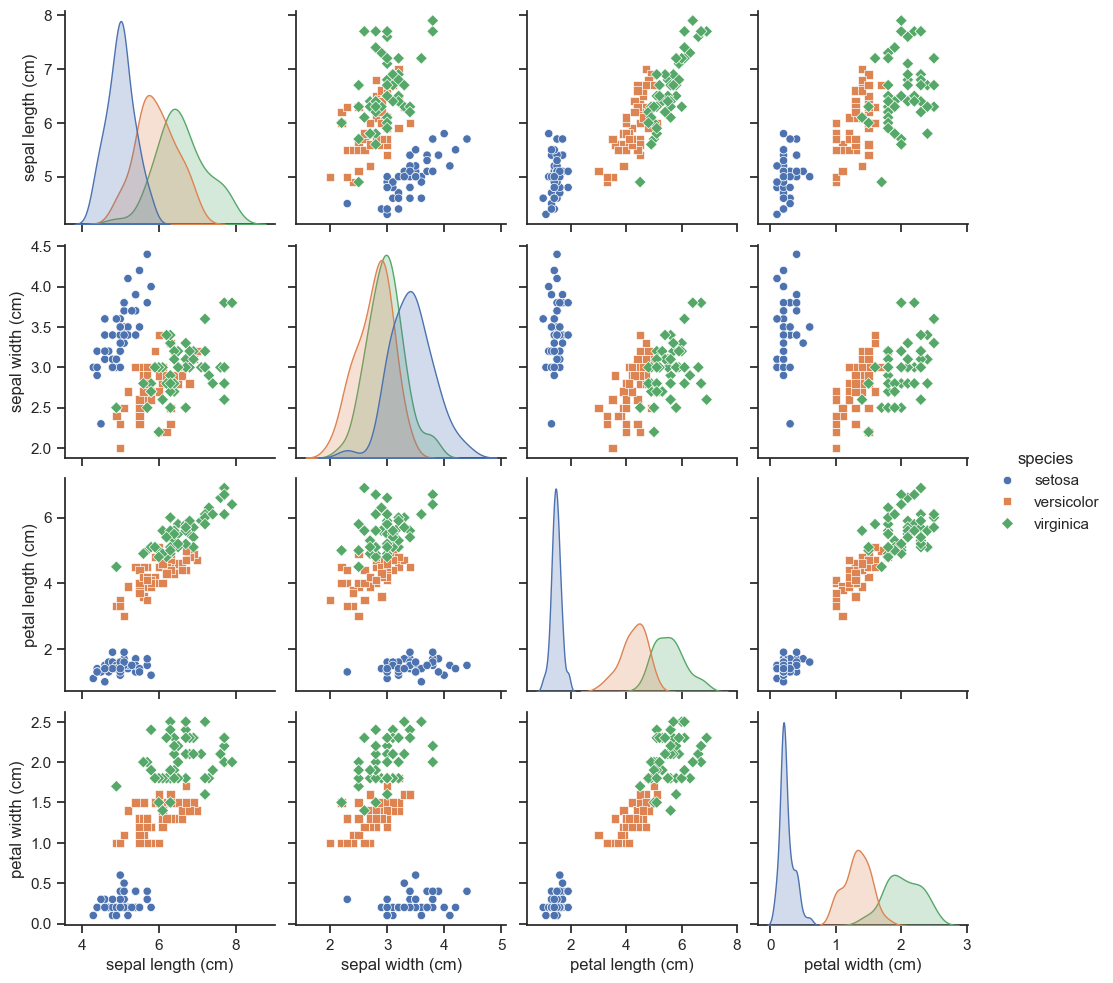

In [4]:
# Enable inline plotting for matplotlib
%matplotlib inline

# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="ticks")

# Generate the pairplot colored by the target class 'species'
sns.pairplot(iris_df, hue="species", markers=["o", "s", "D"])

# Display the plot
plt.show()

### SECTION 3: Binary Logistic Regression - Virginica vs Not Virginica

#### Data Loading & target engineering


In [5]:
#	Create	a	copy	and	add	is_virginica	flag	
virginica_df	=	iris_df.copy()	
virginica_df["is_virginica"]	=	(iris.target	==	2).astype(int)

#	Separate	features	and	label	
X	=	virginica_df[iris.feature_names]	
y	=	virginica_df["is_virginica"]
	
#	Display	rows	
virginica_df.head(150)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,is_virginica
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,1
146,6.3,2.5,5.0,1.9,virginica,1
147,6.5,3.0,5.2,2.0,virginica,1
148,6.2,3.4,5.4,2.3,virginica,1


In [6]:
# Check the class distribution
virginica_df["is_virginica"].value_counts()

is_virginica
0    100
1     50
Name: count, dtype: int64

##### How many samples belong to class 1 vs class 0 ?
Class 1 (Virginica): 50 samples.  
Class 0 (Not Virginica): 100 samples

##### Why is it useful to convert the target to 0/1 for binary classification?
Logistic regression calculates probabilities using the sigmoid function and binary cross-entropy loss, which explicitly require numerical binary labels ($0$ and $1$).

It clearly defines the positive class ($1 = \text{Virginica}$) and the negative class ($0 = \text{Not Virginica}$), which is required to compute metrics like Precision, Recall, and F1-score.

#### Train/Test split (with stratification)

In [7]:
#	Train_split	with	stratification	
from	sklearn.model_selection	import	train_test_split	
X_train,	X_test,	y_train,	y_test	=	train_test_split(X,	y,	test_size=0.30,	random_state=42,	
stratify=y)	
y_train.value_counts(),	y_test.value_counts()

(is_virginica
 0    70
 1    35
 Name: count, dtype: int64,
 is_virginica
 0    30
 1    15
 Name: count, dtype: int64)

##### What does stratify=y ensure during the split? Why is it useful to stratify a dataset when splitting it into training and test sets? 

It guarantees that the training and test sets maintain the exact same class proportions as the original dataset.
It prevents sampling bias and class imbalance distortion, ensuring the test set is representative and the model doesn't over- or under-train on a specific class.

##### What are the class counts in train vs test datasets? 

Train Set (105 samples) --> Class 0: 70
                        --> Class 1: 35

Test Set (45 samples) --> Class 0: 30
                      --> Class 1: 15

#### Feature Scaling

In [8]:
from	sklearn.preprocessing	import	StandardScaler	
scaler	=	StandardScaler().fit(X_train)	
X_train_std	=	scaler.transform(X_train)	
X_test_std		=	scaler.transform(X_test)

#### Binary Logistic regression on standardized features

In [9]:
from	sklearn.linear_model	import	LogisticRegression	
logreg	=	LogisticRegression(max_iter=500,	solver="lbfgs")	
logreg.fit(X_train_std,	y_train)	
print("Coefficients	(per	feature):",	dict(zip(iris.feature_names,	logreg.coef_[0])))	
print("Intercept:",	logreg.intercept_[0])	

Coefficients	(per	feature): {'sepal length (cm)': np.float64(0.5435686295344357), 'sepal width (cm)': np.float64(-0.3396157602267347), 'petal length (cm)': np.float64(1.8786291737814038), 'petal width (cm)': np.float64(2.7376368640947257)}
Intercept: -3.44190347855401


##### Which features have positive coefficients? What does a positive sign mean here?

positive coefficients: sepal length, petal length, petal width
A positive sign means an increase in this feature value raises the probability that the flower belongs to the positive class (Virginica)

##### Which single feature appears most predictive of Virginica?

Most predictive feature: petal width
Because the features were standardized, their coefficients are directly comparable. Petal width has the largest positive magnitude, it contributes most heavily to classifying.

#### Predict labels and probabilities

In [10]:
#	Import	necessary	libraries	
import	numpy	as	np	
from	sklearn.metrics	import	accuracy_score,	classification_report,	confusion_matrix	

#	Use	the	trained	logistic	regression	model	(logreg)	to	make	predictions	on	the	standardized	test	set	
y_pred	=	logreg.predict(X_test_std)	

#	Compute	the	predicted	probabilities	for	the	positive	class	(Virginica	=	1)	

#	predict_proba	returns	probabilities	for	all	classes;	[:,	1]	selects	the	column	for	class	1	
y_proba	=	logreg.predict_proba(X_test_std)[:,	1]	

#	Evaluate	model	performance	

#	Print	the	overall	accuracy	of	the	model	
print("Accuracy:",	accuracy_score(y_test,	y_pred))	

#	Print	a	detailed	classification	report	(precision,	recall,	f1-score,	support)	for	each	class	
print(classification_report(y_test,	y_pred,	target_names=["Not	Virginica",	"Virginica"]))	

#	Print	the	confusion	matrix	to	see	the	distribution	of	correct	and	incorrect	predictions	
print("Confusion	matrix:\n",	confusion_matrix(y_test,	y_pred))	

Accuracy: 0.9333333333333333
               precision    recall  f1-score   support

Not	Virginica       0.91      1.00      0.95        30
    Virginica       1.00      0.80      0.89        15

     accuracy                           0.93        45
    macro avg       0.95      0.90      0.92        45
 weighted avg       0.94      0.93      0.93        45

Confusion	matrix:
 [[30  0]
 [ 3 12]]


#### Threshold tuning

In [11]:
# Import evaluation metric function
from sklearn.metrics import precision_recall_fscore_support

# Define a helper function to evaluate metrics at a given probability threshold
def evaluate_at(th):
    # Classify as positive (1) if probability >= threshold, else negative (0)
    y_hat = (y_proba >= th).astype(int)
    
    # Compute precision, recall, and F1-score for the positive class (Virginica)
    p, r, f1, _ = precision_recall_fscore_support(
        y_test, y_hat, average="binary", zero_division=0
    )
    return th, p, r, f1

# Evaluate and print results across different decision thresholds
print("--- Threshold Tuning Results ---")
for th in [0.3, 0.5, 0.7]:
    th, p, r, f1 = evaluate_at(th)
    print(f"Threshold = {th:.2f} | Precision = {p:.3f} | Recall = {r:.3f} | F1-Score = {f1:.3f}")

--- Threshold Tuning Results ---
Threshold = 0.30 | Precision = 0.875 | Recall = 0.933 | F1-Score = 0.903
Threshold = 0.50 | Precision = 1.000 | Recall = 0.800 | F1-Score = 0.889
Threshold = 0.70 | Precision = 1.000 | Recall = 0.667 | F1-Score = 0.800


##### Pick a use case where high recall for Virginica is critical.  

Example scenario: Identifying an endangered or medically vital plant species where missing a single true sample (False Negative) is unacceptable.

##### Which threshold would you choose and why? 

A lower threshold (th=0.30), lowering the decision threshold makes the model more sensitive, reducing False Negatives and maximizing Recall so that almost every Virginica flower is successfully detected.

### SECTION 4: Classification Task

#### Preprocessing & Train-Test Split

In [12]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset and prepare features (X) and multiclass target (y)
iris = load_iris()
X = pd.DataFrame(data=iris.data, columns=iris.feature_names)
y = iris.target  # 0: setosa, 1: versicolor, 2: virginica

# Stratified split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Standardize features using StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

#### Train Multinomial Logistic Regression & Evaluate

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Logistic Regression model (multinomial by default with lbfgs)
model = LogisticRegression(max_iter=200, solver="lbfgs", random_state=42)
model.fit(X_train_std, y_train)

# Predict on the test set
y_pred = model.predict(X_test_std)

# Evaluation metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy Score: 0.9111111111111111

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



#### Inspect Learned Parameters (Coefficients & Intercepts)

In [15]:
# Feature names and class names
feature_names = X.columns.to_list()
class_names = iris.target_names

# Build a readable DataFrame of learned weights and intercepts
coef_df = pd.DataFrame(model.coef_, index=class_names, columns=feature_names)
intercepts = pd.Series(model.intercept_, index=class_names)

print("Standardized-space coefficients (rows=classes, cols=features):")
print(coef_df)
print("\nStandardized-space intercepts (per class):")
print(intercepts)

Standardized-space coefficients (rows=classes, cols=features):
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa              -1.077291          0.954588          -1.699549   
versicolor           0.473373         -0.447111          -0.116408   
virginica            0.603918         -0.507477           1.815957   

            petal width (cm)  
setosa             -1.602910  
versicolor         -0.793047  
virginica           2.395958  

Standardized-space intercepts (per class):
setosa       -0.330410
versicolor    1.786567
virginica    -1.456157
dtype: float64


#### Classify the New Observation

In [16]:
# Create DataFrame for the new sample
new_obs = pd.DataFrame([{
    "sepal length (cm)": 6.1,
    "sepal width (cm)": 2.8,
    "petal length (cm)": 5.0,
    "petal width (cm)": 1.9
}])

# Standardize the new observation using the fitted scaler
new_obs_std = scaler.transform(new_obs[X.columns])

# Predict class index and map to species name
pred_idx = model.predict(new_obs_std)[0]
pred_class = iris.target_names[pred_idx]

# Predicted class probabilities
proba = pd.Series(
    model.predict_proba(new_obs_std)[0],
    index=iris.target_names
).sort_values(ascending=False)

print("Predicted class:", pred_class)
print("\nClass probabilities:\n", proba)

Predicted class: virginica

Class probabilities:
 virginica     0.731726
versicolor    0.266685
setosa        0.001589
dtype: float64


##### Based on your trained model above, to which class would this be assigned? Why?

The sample is classified as virginica because the model outputs its highest probability ($73.2\%$) for this class. Its large petal measurements ($5.0\text{ cm}$ length, $1.9\text{ cm}$ width) strongly match the learned positive weights for Virginica.